<a href="https://colab.research.google.com/github/Samikshya-mohanty/datascience_assignments/blob/main/samikshya_mohanty_PGDSE_Batch1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/content/superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


## Q1: Data Cleaning:

In [3]:
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51285.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.378062,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.299145,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [5]:
df['Ship.Date'].isnull()

,Ship.Date
0,False
1,False
2,False
3,False
4,False
...,...
51285,False
51286,False
51287,False
51288,False


In [6]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [7]:
# Drop the unwanted column
df = df.drop('记录数',axis=1)

In [8]:
df.head(2)

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,00:00.0,CA-2011-130813,High,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,00:00.0,CA-2011-148614,Medium,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4


In [10]:
# Convert dates to datetime objects for analysis
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

In [11]:
# Finding missing values
df.isna().sum()

,0
Category,0
City,0
Country,0
Customer.ID,0
Customer.Name,0
Discount,0
Market,0
Order.Date,0
Order.ID,0
Order.Priority,0


<Axes: >

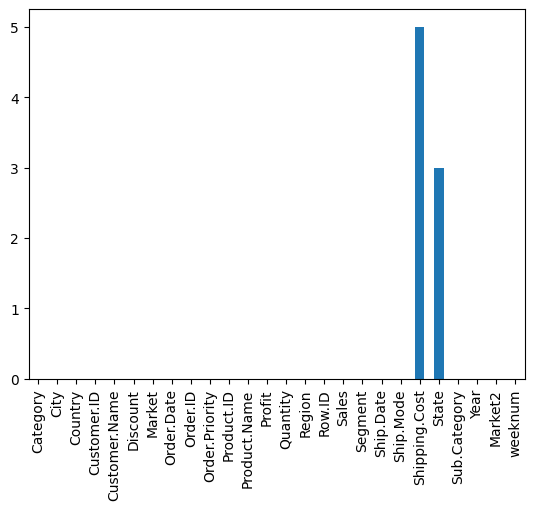

In [12]:
df.isna().sum().plot(kind='bar')

In [13]:
df.shape


(51290, 26)

In [14]:
df.size


1333540

In [15]:
df.isna().sum(axis=1)

,0
0,0
1,0
2,0
3,0
4,0
...,...
51285,0
51286,0
51287,0
51288,0


<Axes: >

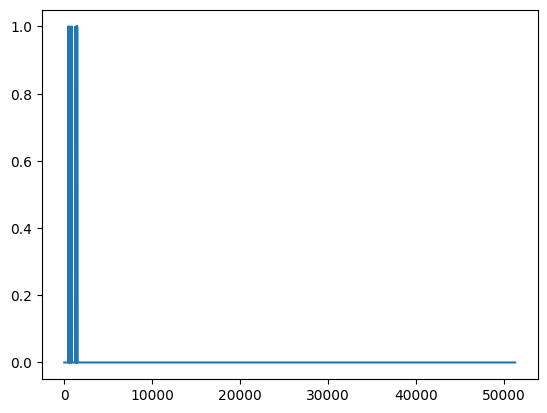

In [16]:
df.isna().sum(axis=1).plot()

# Better way to visualize is using seaborn along with the heatmap

In [17]:
import seaborn as sns

In [18]:
df.isna()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
51286,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
51287,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
51288,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


<Axes: >

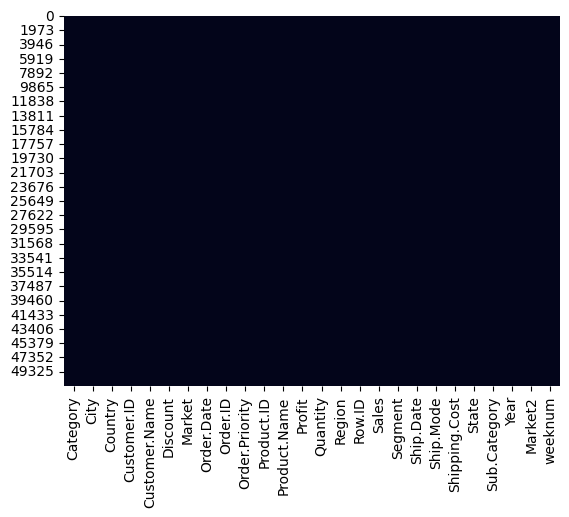

In [19]:
sns.heatmap(df.isna(), cbar=False)

## Now dealing with the missing values

In [20]:
df['Shipping.Cost'] = df['Shipping.Cost'].fillna(df['Shipping.Cost'].median())

## Q2: Perform Univariate Analysis across all numerical features

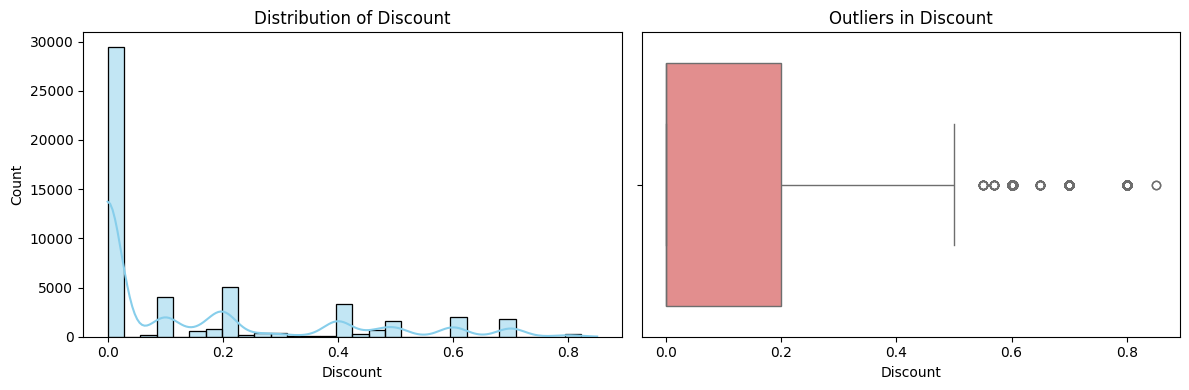

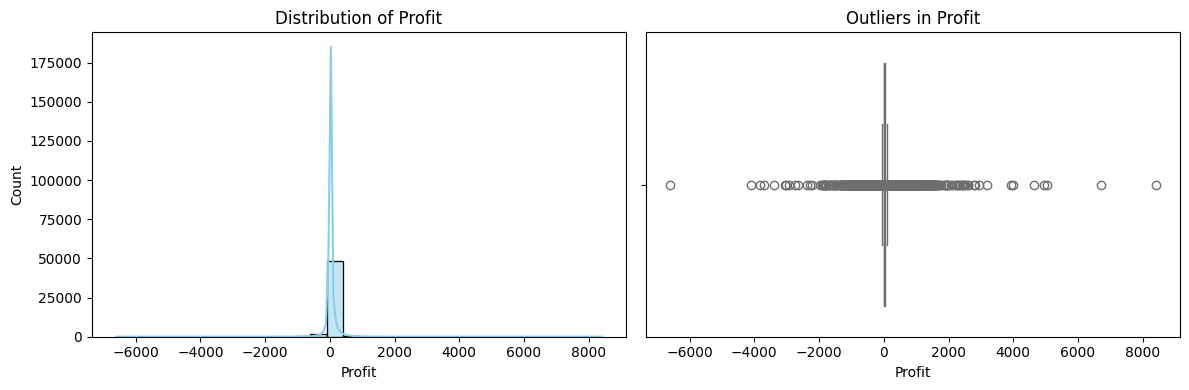

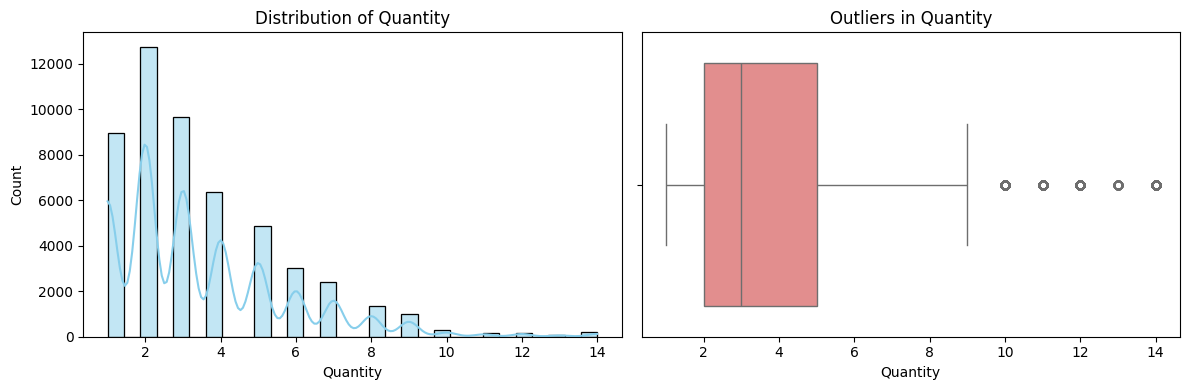

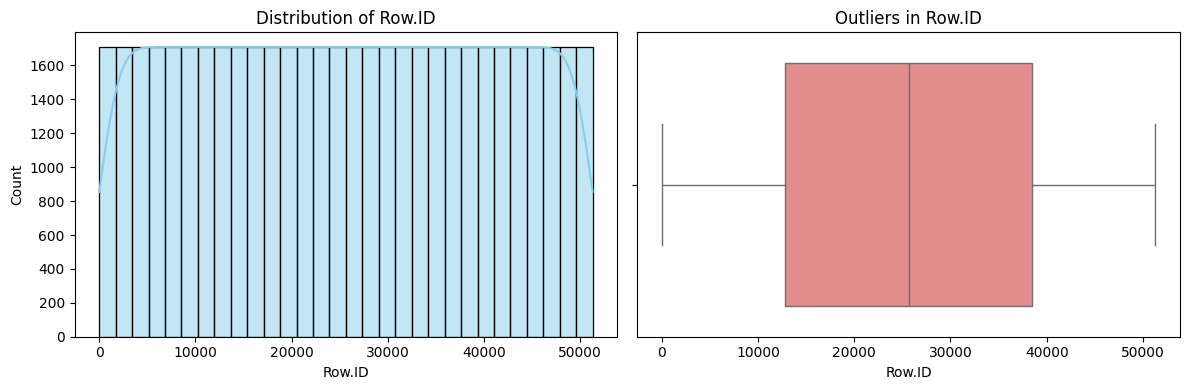

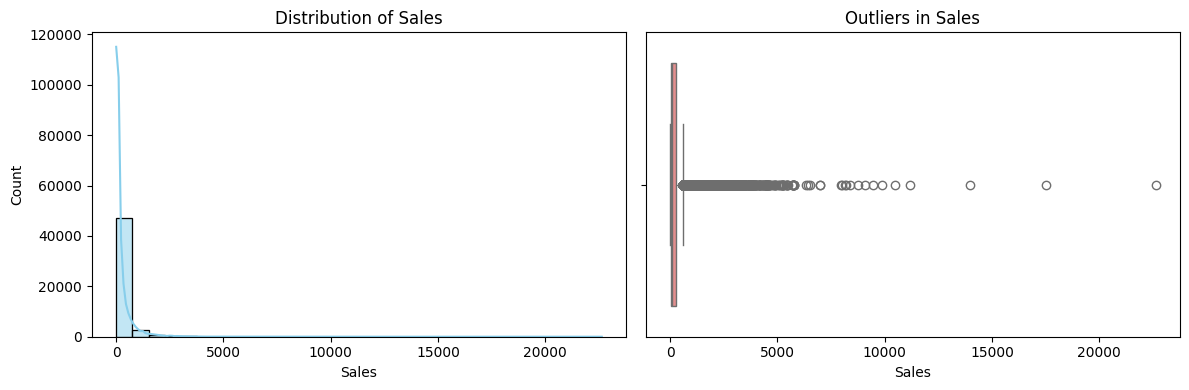

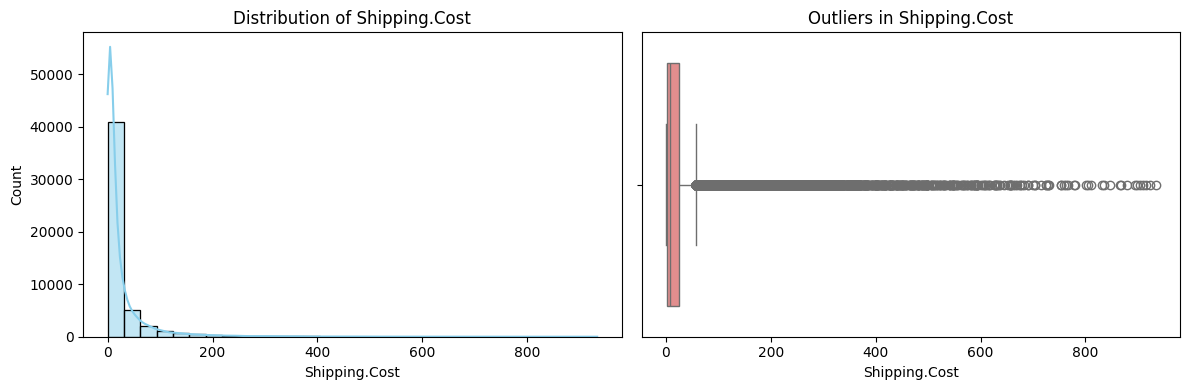

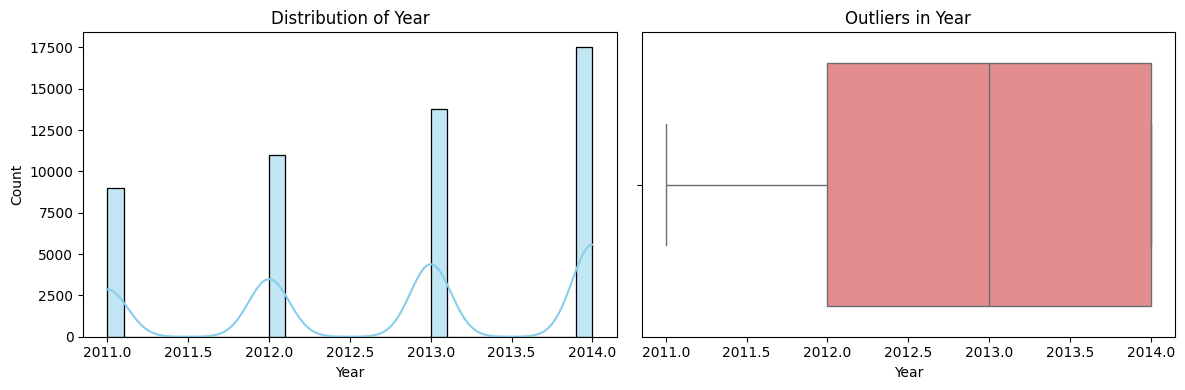

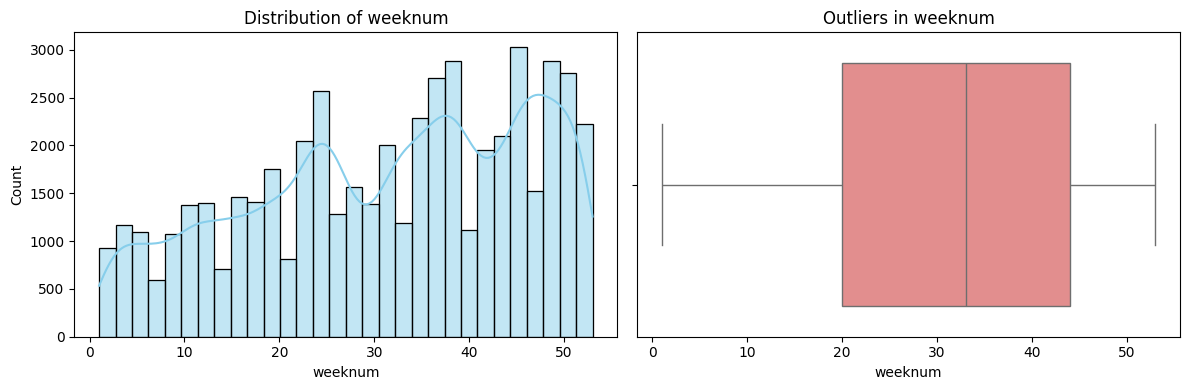

Skewness values:
 Discount         1.387775e+00
Profit           4.157189e+00
Quantity         1.360368e+00
Row.ID           9.010420e-18
Sales            8.137981e+00
Shipping.Cost    5.863256e+00
Year            -3.445153e-01
weeknum         -3.424505e-01
dtype: float64


In [21]:
# 1. Identify numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# 2. Visual Analysis: Histograms and Boxplots
for col in num_cols:
    plt.figure(figsize=(12, 4))

    # Histogram for distribution
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')

    # Boxplot for outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Outliers in {col}')

    plt.tight_layout()
    plt.show()

# 3. Statistical Analysis: Skewness
print("Skewness values:\n", df[num_cols].skew())

### i. Which features seem useless in the analysis? Explain why?
Row.ID is a unique identifier and does not represent a trend. Including it in a statistical model would lead to noise.

ii. Which features are uniformly distributed or normally distributed?
Year and weeknum are uniformly distributed.
None of the core business metrics (Sales, Profit) are normally distributed

iii. Which features are right-skewed/left-skewed? What does this signify?
Right-Skewed (Positive Skew): Sales, Profit, Shipping.Cost, and Quantity.

Insight: Both are highly skewed, suggesting most transactions are small with a few very large sales/profits.

In [22]:
# Median Sales and Profit by Category
cat_stats = df.groupby('Category').agg({'Sales': 'median', 'Profit': 'median'})
cat_stats

,Sales,Profit
Category,,
Furniture,220.0,15.5022
Office Supplies,46.0,6.5538
Technology,260.0,29.9400


In [23]:
# Sales and Profit by Segment
seg_stats = df.groupby('Segment').agg({'Sales': 'median', 'Profit': 'median'})
seg_stats

,Sales,Profit
Segment,,
Consumer,85.0,9.1800
Corporate,85.0,9.3152
Home Office,85.0,9.3200


# Profit outliers

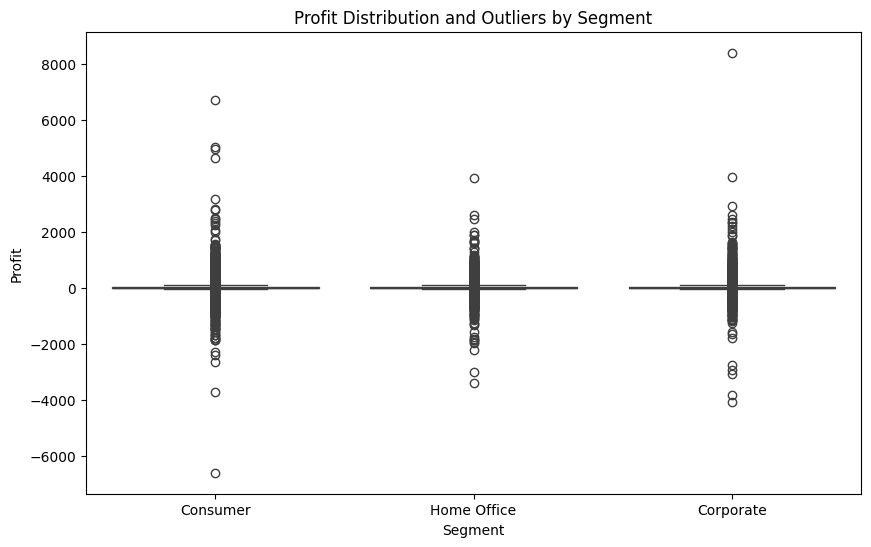

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segment', y='Profit', data=df)
plt.title('Profit Distribution and Outliers by Segment')
plt.show()

We can conclude that Look for the segment with the longest tails below zero;
usually, Consumer or Corporate segments show the most extreme negative profit outliers.

## Q3: Perform Univariate Analysis across all categorical features.

Customer Name is a poor categorical feature for modeling because it has too many unique values (high cardinality), which leads to overfitting.

/tmp/ipython-input-3926022688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')


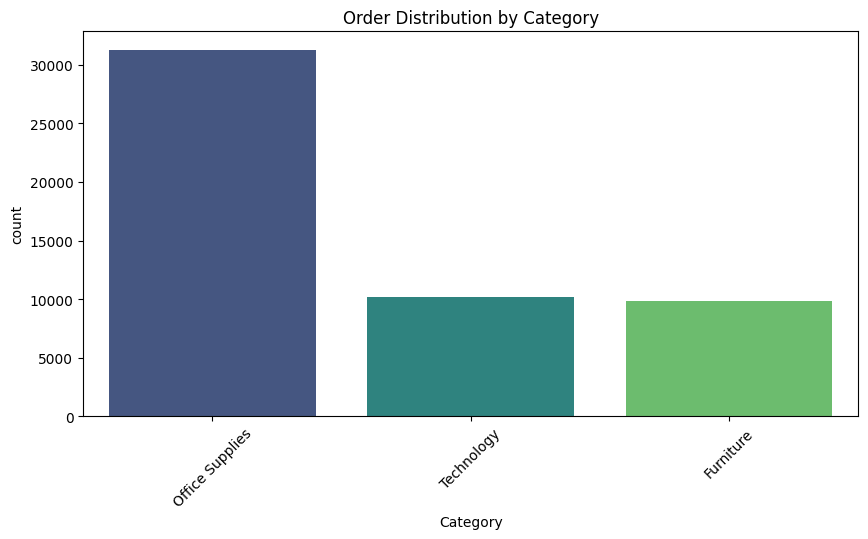

/tmp/ipython-input-3926022688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')


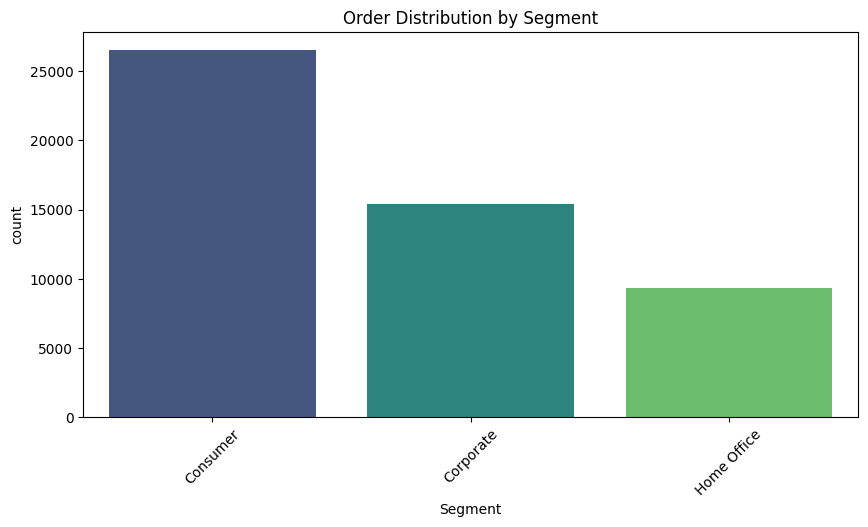

/tmp/ipython-input-3926022688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')


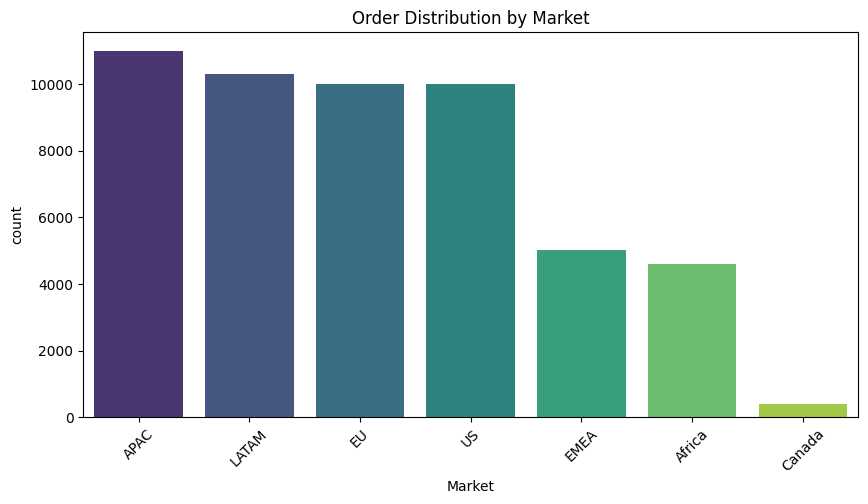

/tmp/ipython-input-3926022688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')


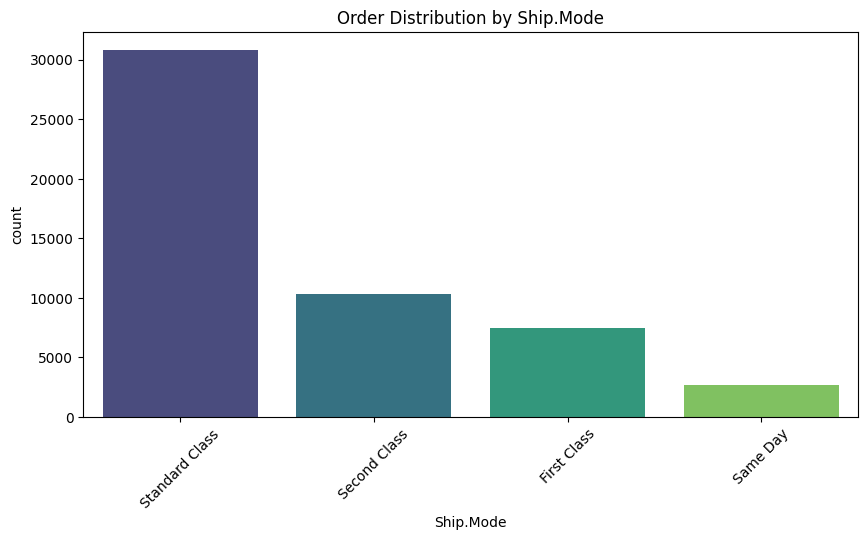

/tmp/ipython-input-3926022688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')


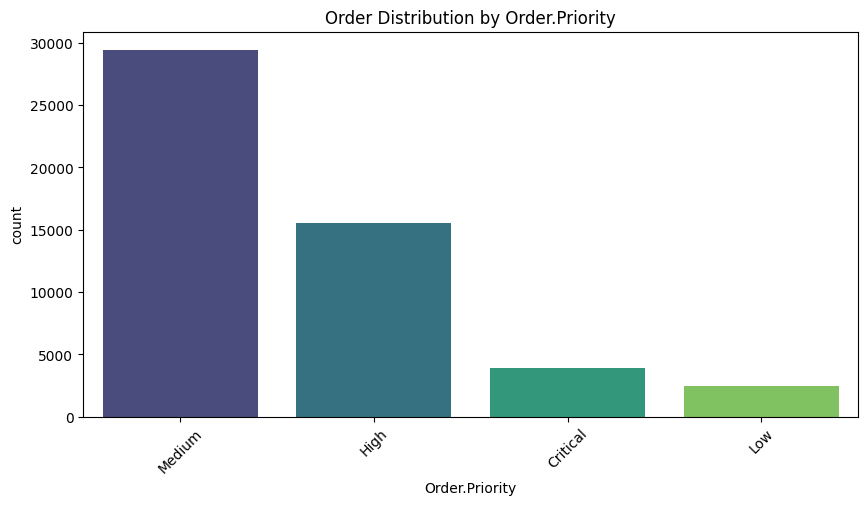

Top 10 Countries by Orders:
 Country
United States     9994
Australia         2837
France            2827
Mexico            2644
Germany           2065
China             1880
United Kingdom    1633
Brazil            1599
India             1555
Indonesia         1390
Name: count, dtype: int64

Total Unique Cities: 3636


In [26]:
# List of main categorical features to analyze
cat_features = ['Category', 'Segment', 'Market', 'Ship.Mode', 'Order.Priority']

# Plot distributions for main categories
for col in cat_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Order Distribution by {col}')
    plt.xticks(rotation=45)
    plt.show()

# Geographic analysis for Country and City
print("Top 10 Countries by Orders:\n", df['Country'].value_counts().head(10))
print(f"\nTotal Unique Cities: {df['City'].nunique()}")

i. Which features seem inaccurate and are not useful as categorical “insights” directly: Row.ID, Order.ID, Customer.ID, and Product.ID are unique identifiers. They are not useful for categorical insights.

ii. What’s the issue with treating Customer.Name as a categorical feature for modeling: The most immediate issue is High Cardinality. This means the feature has a very large number of unique values (categories).

iii. Is the Category distribution balanced or skewed? Give a 1-line reason: It is skewed (specifically toward Office Supplies).Office Supplies accounts for over 60% of all orders, which is more than triple the volume of either Technology or Furniture

iv. In Country, does one country dominate strongly? What does that imply about
geographic bias: United States dominates,the highest sales are from USA.

v. Is the City dataset concentrated in a few cities or spread out:
The City dataset is Spread Out.


## Q 4: Perform Bivariant Analysis for numerical-to-numerical features:

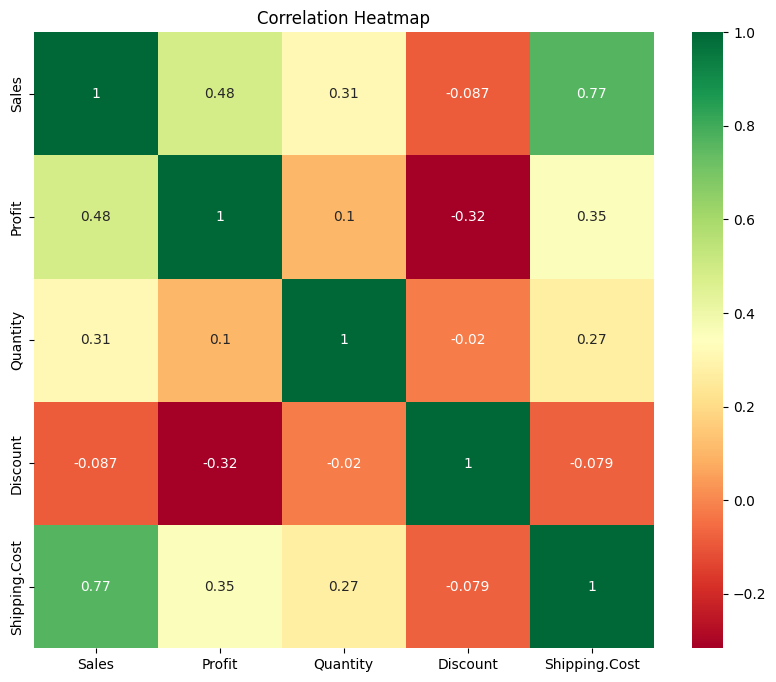

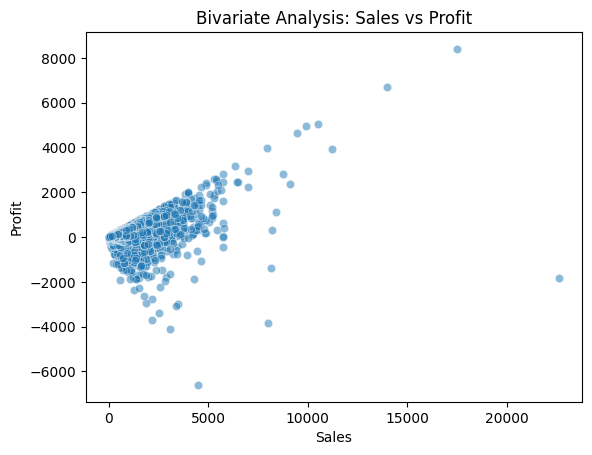

In [27]:
# Define numerical features for correlation analysis
num_features = ['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping.Cost']

plt.figure(figsize=(10, 8))
correlation_matrix = df[num_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()

# Profit analysis: Sales vs Profit
sns.scatterplot(data=df, x='Sales', y='Profit', alpha=0.5)
plt.title('Bivariate Analysis: Sales vs Profit')
plt.show()

Look for Time Effects Clues. Mention any information you find about the time
relationship with any feature.

In [28]:
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

In [29]:
# ship delay time
df['Ship_delay'] = (df['Ship.Date'] - df['Order.Date']).dt.days

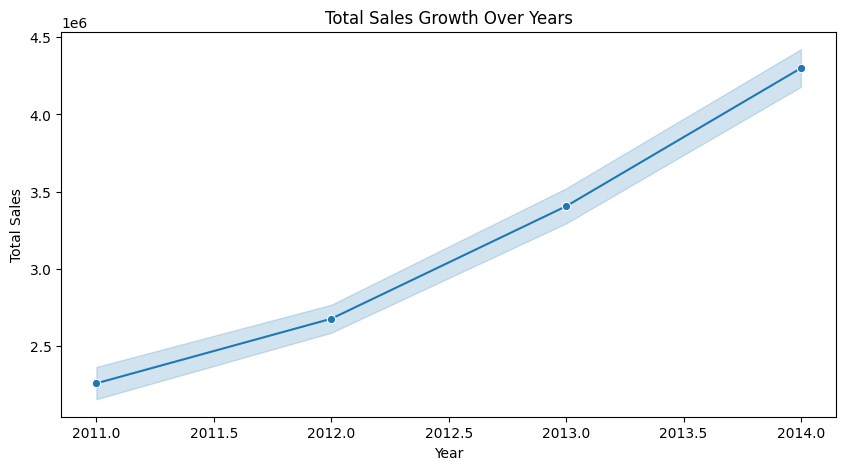

In [30]:
# Visualizing Sales Trends over Years
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Year', y='Sales', estimator='sum', marker='o')
plt.title('Total Sales Growth Over Years')
plt.ylabel('Total Sales')
plt.show()

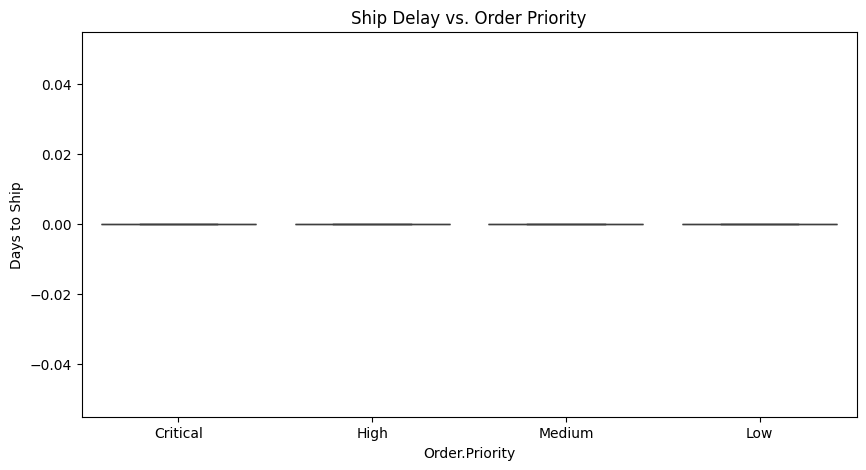

In [31]:
# Relationship between Order Priority and Ship Delay
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Order.Priority', y='Ship_delay', order=['Critical', 'High', 'Medium', 'Low'])
plt.title('Ship Delay vs. Order Priority')
plt.ylabel('Days to Ship')
plt.show()

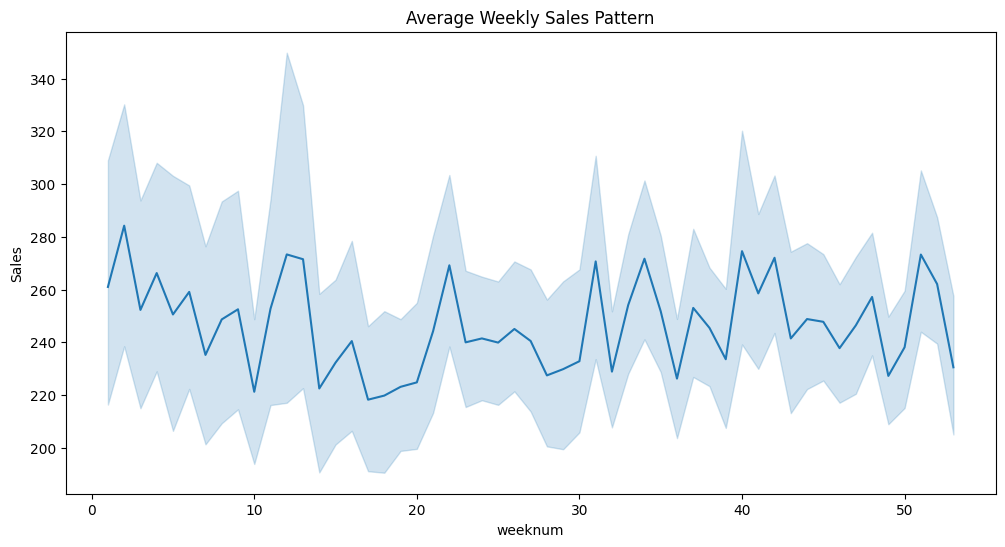

In [32]:
# Analyzing Weekly Seasonality (using weeknum)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='weeknum', y='Sales', estimator='mean')
plt.title('Average Weekly Sales Pattern')
plt.show()

i. Which two features are most strongly correlated: The features Sales and Shipping Cost show the strongest positive correlation at approximately 0.7681.

ii. Also name features that are negatively correlated: Discount and Profit, Discount and Sales,Discount and Shipping Cost, Discount and Quantity has weak negative correlation.

iii. Most useful next bivariate checks to understand Profit: Profit vs. Sales is moderately positive correlation, Profit vs. Shipping Cost has the positive correlation

iv. Time Effects Clues: Both Year and weeknum show near-zero correlation with Sales and Profit. This implies that while there may be seasonal spikes.

## Q 5: Perform Bi-variant Analysis for categorical to numerical features.:

In [33]:
# Calculate IQR and Median
profit_stats = df.groupby('Category')['Profit'].agg(['median', lambda x: x.quantile(0.75) - x.quantile(0.25)])
profit_stats.columns = ['Median_Profit', 'IQR_Profit']
print(profit_stats)

                 Median_Profit  IQR_Profit
Category                                  
Furniture              15.5022      81.535
Office Supplies         6.5538      20.130
Technology             29.9400      98.350


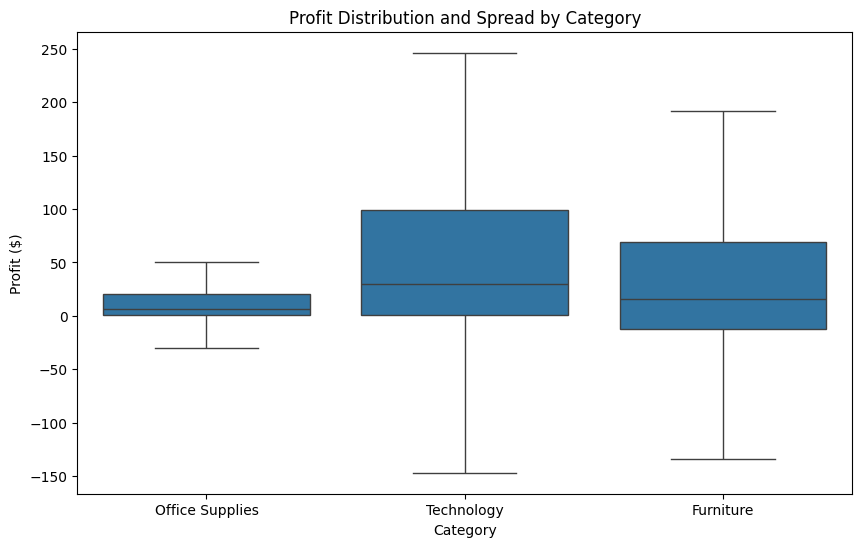

In [34]:
# Visualize with a Boxplot to show spread and consistency
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Profit', data=df, showfliers=False) # showfliers=False hides extreme outliers for better visibility of IQR
plt.title('Profit Distribution and Spread by Category')
plt.ylabel('Profit ($)')
plt.show()

i. Profit by Category: Highest profit median: Technology (Median Profit: $29.94).

Lowest median profit: Office Supplies (Median Profit: $6.55).



In [35]:
stats = df.groupby('Category')[['Sales', 'Profit']].agg(['median', lambda x: x.quantile(0.75) - x.quantile(0.25)])
stats.columns = ['Median_Sales', 'IQR_Sales', 'Median_Profit', 'IQR_Profit']
print(stats)

                 Median_Sales  IQR_Sales  Median_Profit  IQR_Profit
Category                                                           
Furniture               220.0      418.0        15.5022      81.535
Office Supplies          46.0       85.0         6.5538      20.130
Technology              260.0      438.0        29.9400      98.350


ii. Sales by Category : Technology has the highest median sales at $\$260.0$.


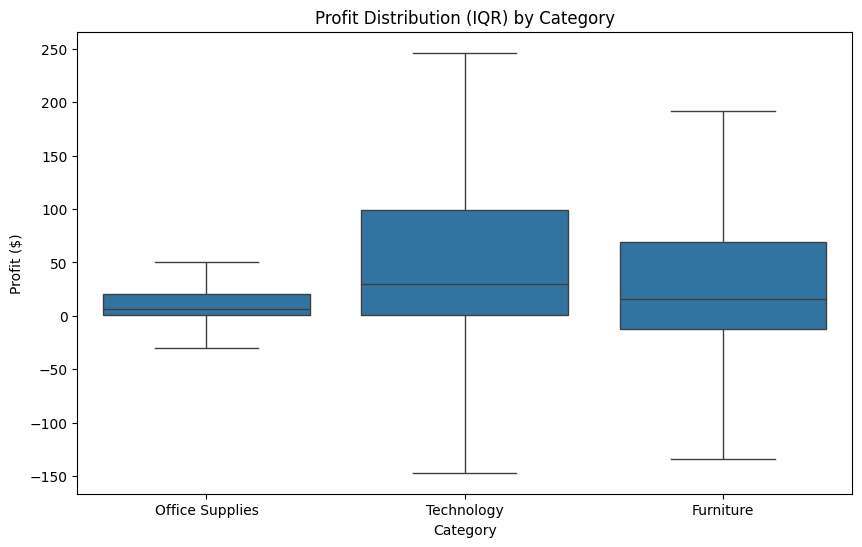

In [36]:
# Visualize Profit Spread (IQR)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Profit', data=df, showfliers=False)  # showfliers=False focuses on the IQR
plt.title('Profit Distribution (IQR) by Category')
plt.ylabel('Profit ($)')
plt.show()

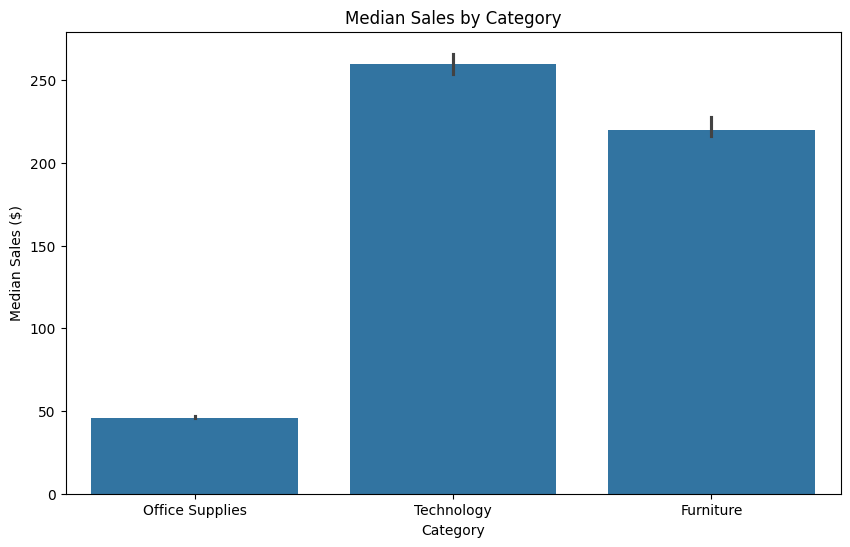

In [37]:
# Visualize Median Sales
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sales', data=df, estimator=lambda x: pd.Series(x).median())
plt.title('Median Sales by Category')
plt.ylabel('Median Sales ($)')
plt.show()

Q5 iv. Sales by Segment

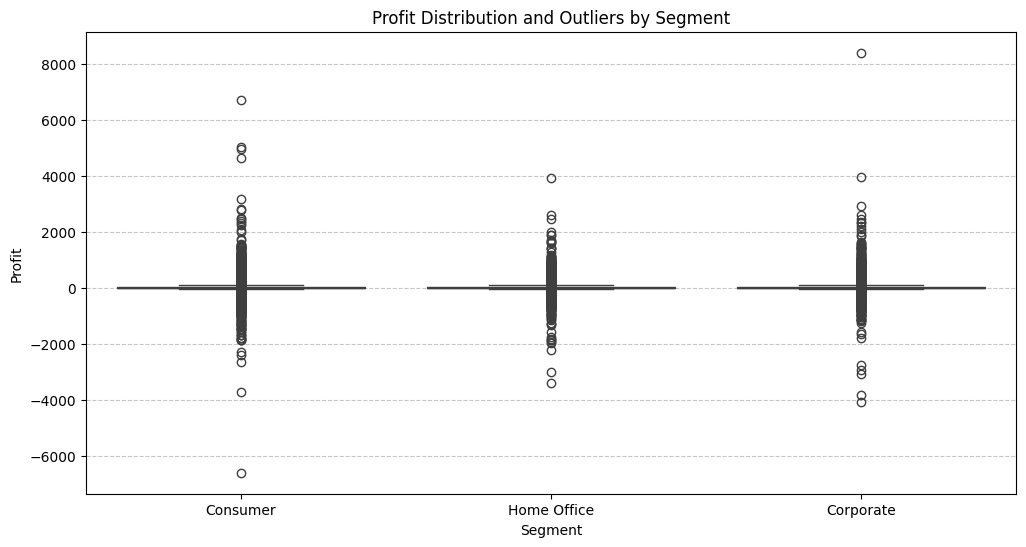

In [38]:
segment_profit_median = df.groupby('Segment')['Profit'].median().sort_values(ascending=False)
segment_profit_median
# 2. Visualize Profit Spread and Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x='Segment', y='Profit', data=df)
plt.title('Profit Distribution and Outliers by Segment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

iii. Profit by Segment: We can conculde that "Home Office" has the highest median profit


iv. Sales by Segment: Which segment has the highest median sales? Is the profit pattern consistent with sales?

/tmp/ipython-input-3800673921.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales_median.index, y=segment_sales_median.values, ax=ax1, palette='Blues_d', alpha=0.6)


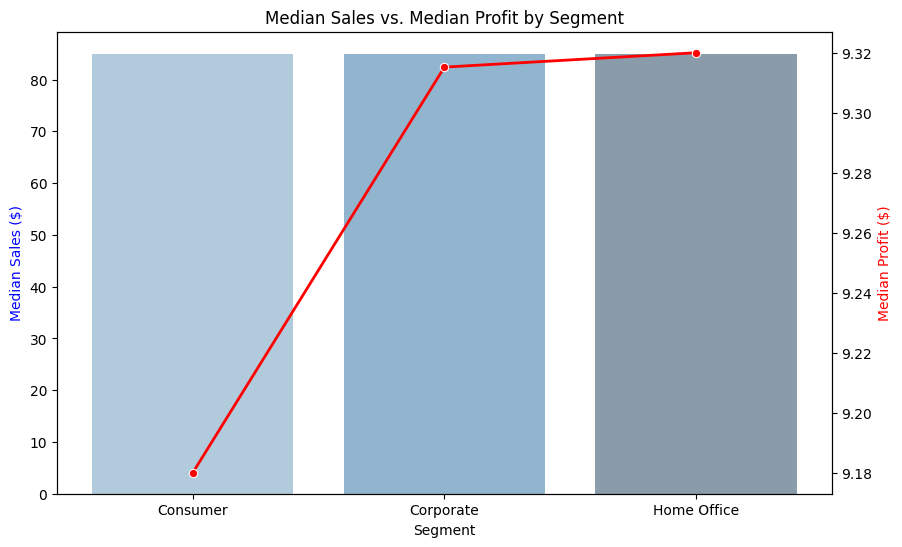

In [39]:
segment_sales_median = df.groupby('Segment')['Sales'].median().sort_values(ascending=False)
segment_sales_median

# Visualization: Comparing Sales and Profit Medians
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Median Sales
sns.barplot(x=segment_sales_median.index, y=segment_sales_median.values, ax=ax1, palette='Blues_d', alpha=0.6)
ax1.set_ylabel('Median Sales ($)', color='blue')
ax1.set_title('Median Sales vs. Median Profit by Segment')

# Line plot for Median Profit (on a secondary axis)
ax2 = ax1.twinx()
sns.lineplot(x=segment_profit_median.index, y=segment_profit_median.values, ax=ax2, marker='o', color='red', linewidth=2)
ax2.set_ylabel('Median Profit ($)', color='red')

plt.show()

All segments (Consumer, Corporate, and Home Office) are tied with a median sales value of $85.0.

Yes, the pattern is consistent. Since the median sales are identical across all segments

## Q 6: Perform Bivariate Analysis for Market features against Region, Category, and Country:

i. Is the Market is not randomly spread across all Regions?

In [40]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum,Ship_delay
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2026-01-29,CA-2011-130813,High,...,Consumer,2026-01-29,Second Class,4.37,California,Paper,2011,North America,2,0
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2026-01-29,CA-2011-148614,Medium,...,Consumer,2026-01-29,Standard Class,0.94,California,Paper,2011,North America,4,0
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2026-01-29,CA-2011-118962,Medium,...,Consumer,2026-01-29,Standard Class,1.81,California,Paper,2011,North America,32,0
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2026-01-29,CA-2011-118962,Medium,...,Consumer,2026-01-29,Standard Class,4.59,California,Paper,2011,North America,32,0
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2026-01-29,CA-2011-146969,High,...,Consumer,2026-01-29,Standard Class,1.32,California,Paper,2011,North America,40,0


Market vs. Region Mapping:
 Region  Africa  Canada  Caribbean  Central  Central Asia  EMEA  East  North  \
Market                                                                        
APAC         0       0          0        0          2048     0     0      0   
Africa    4587       0          0        0             0     0     0      0   
Canada       0     384          0        0             0     0     0      0   
EMEA         0       0          0        0             0  5029     0      0   
EU           0       0          0     5822             0     0     0   2141   
LATAM        0       0       1690     2972             0     0     0   2644   
US           0       0          0     2323             0     0  2848      0   

Region  North Asia  Oceania  South  Southeast Asia  West  
Market                                                    
APAC          2338     3487      0            3129     0  
Africa           0        0      0               0     0  
Canada           0      

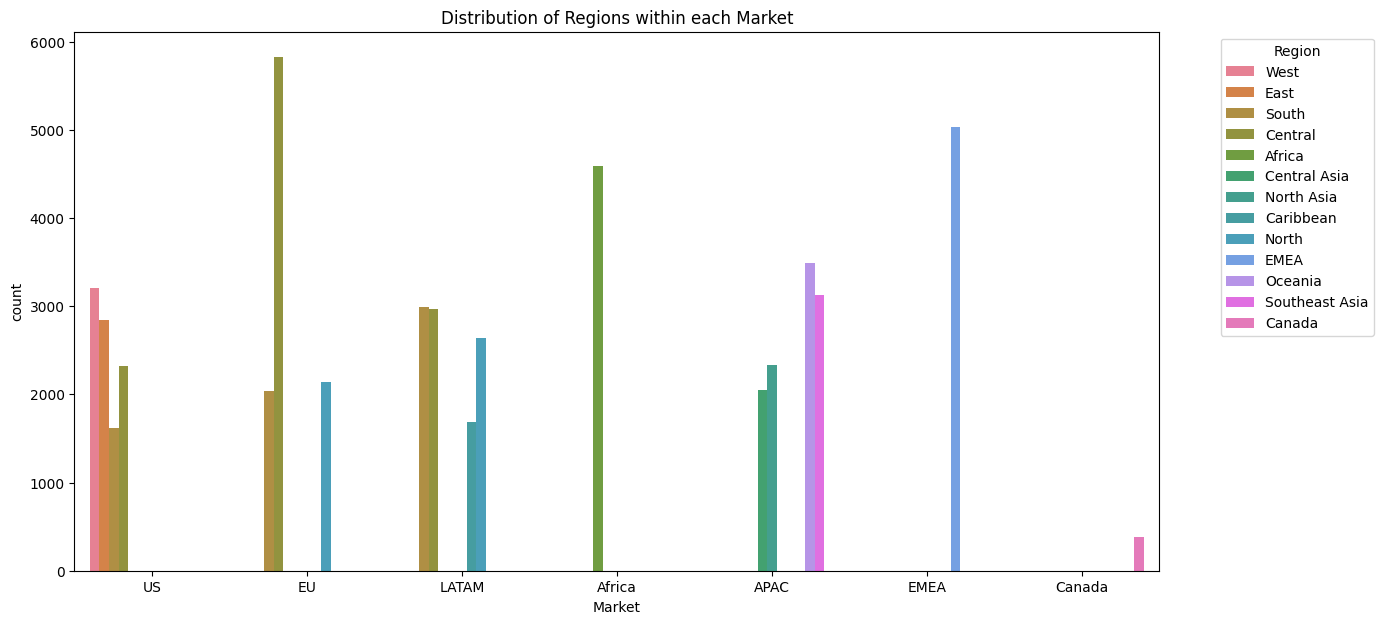

In [41]:
market_region_map = pd.crosstab(df['Market'], df['Region'])
print("Market vs. Region Mapping:\n", market_region_map)

# 2. Visualize the distribution
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='Market', hue='Region')
plt.title('Distribution of Regions within each Market')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

No, the Market is not randomly spread.

ii. Which country has negligible office supply orders?

In [42]:
office_supplies = df[df['Category'] == 'Office Supplies']

negligible_countries = office_supplies['Country'].value_counts().sort_values(ascending=True)

print("Countries with negligible (lowest) Office Supply orders:")
print(negligible_countries.head(10))

Countries with negligible (lowest) Office Supply orders:
Country
Bahrain              1
Swaziland            1
Armenia              1
Eritrea              1
Guadeloupe           2
Slovenia             2
Lesotho              2
Chad                 2
Equatorial Guinea    2
Tajikistan           2
Name: count, dtype: int64


Several countries have negligible orders (only 1 order each), including Armenia, Swaziland, Eritrea, and Bahrain.

##iii. What are the most useful insights?

- The Technology category is the most lucrative (highest median profit), but it is also the most volatile

- There is a strong negative correlation between discounts and profit.

- The Home Office segment is the most consistently profitable per order, despite having the same median sales as other segments.

- A small number of countries and cities drive the majority of sales, while many others have "negligible" activity, highlighting a massive opportunity for expansion or a need to cut costs in low-performing areas.